# Data Analysis

This file will be used to use data analysis and find statistical patterns in the dataset to both get a general overview and a understanding of the relationships between the variables

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# read the csv file
df = pd.read_csv("../data/dataset.csv")

## Overview

Gives a sneak peak of the data and how the table looks like

In [ ]:
# print first 3 records
df.head(3)

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,uptime,power_consumption
0,42.09,13.85,54.09,9.88,96,417,3296,14.89,43.94,12267.07,306.64
1,93.91,91.39,131.30,14.42,251,2500,11223,28.12,66.70,1.38,373.24
2,6.99,34.51,21.54,23.40,49,433,1981,9.77,35.18,4.74,221.34


These will be used in models.ipynb and are what are referred to as the feature adn target columns

In [11]:
# Print column headings with data
print("Column headings:")
for column in df.columns.tolist():
	print("    " + column)

Column headings:
    cpu_utilization
    memory_usage
    disk_io
    network_latency
    process_count
    thread_count
    context_switches
    cache_miss_rate
    temperature
    uptime
    power_consumption


# Graphs

### Scatter Plot

Shows wether the relationship is a direct or inverse proportion, wether there is a positive or negative correlation and how strong

(TLDR: Tighter is better with non zero gradient)

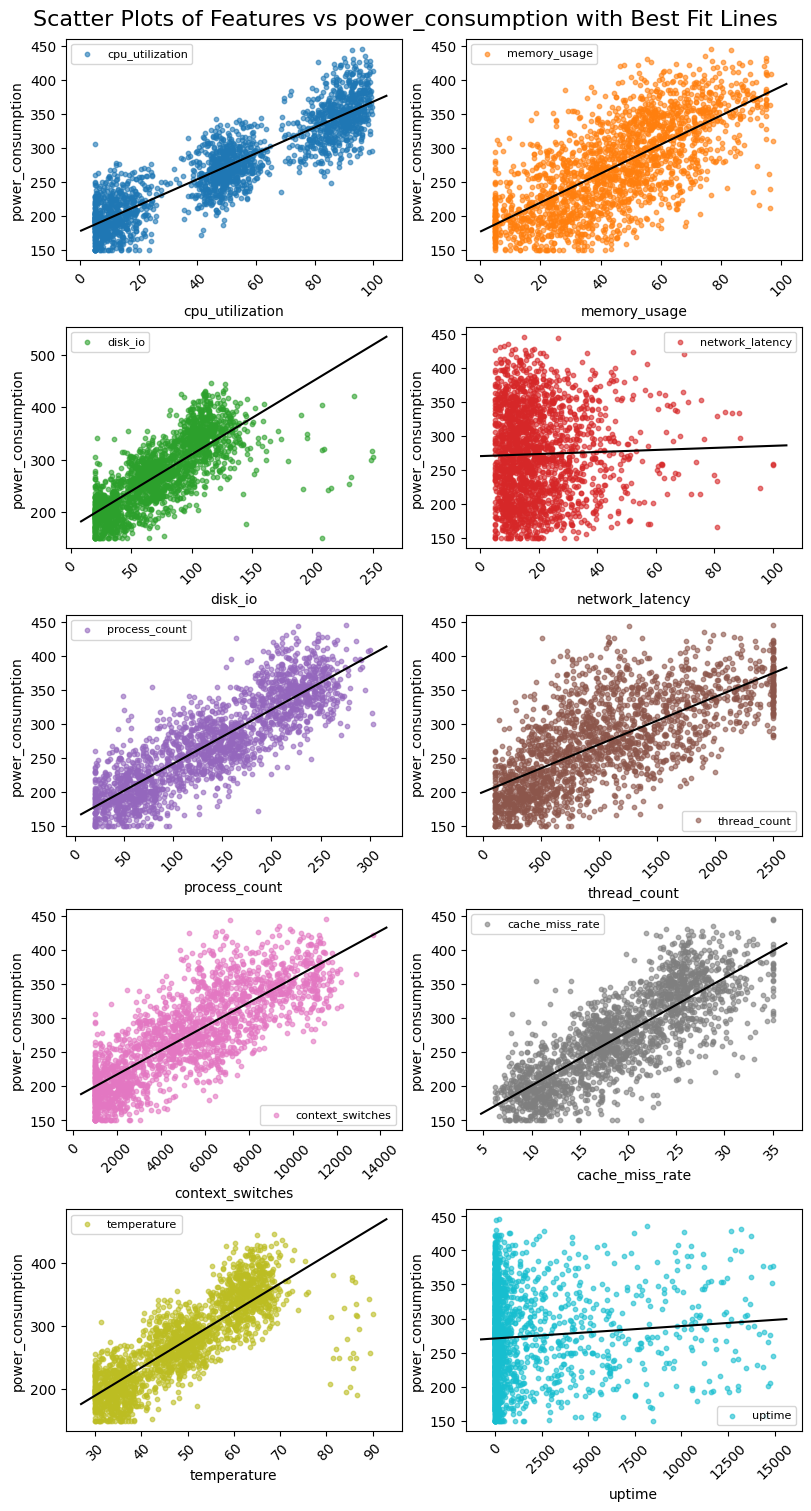

In [12]:
target_column = "power_consumption"
feature_columns = [col for col in df.columns if col != target_column]

# Set up the grid size (e.g., 3 columns)
n_features = len(feature_columns)
cols = 2
rows = (n_features + cols - 1) // cols  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), constrained_layout=True)
axes = axes.flatten()

# Choose color palette
palette = sns.color_palette("tab10", n_features)

for i, feature in enumerate(feature_columns):
    ax = axes[i]
    
    ax.scatter(df[feature], df[target_column], s=10, alpha=0.6, color=palette[i], label=feature)
    
    # Fit and plot regression line in black
    coef = np.polyfit(df[feature], df[target_column], 1)
    x_vals = np.array(ax.get_xlim())
    y_vals = coef[0] * x_vals + coef[1]
    ax.plot(x_vals, y_vals, color='black')
    
    ax.set_xlabel(feature)
    ax.set_ylabel(target_column)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Scatter Plots of Features vs {target_column} with Best Fit Lines', fontsize=16)
plt.show()

### Box and Whisker Plot

Can be used to assess the spread and distribution of each feature, showing the median, quartiles, and potential outliers. Features with very wide spreads may contain extreme outliers that can hurt training, while very narrow spreads indicate little variation and low usefulness. A balanced, moderate spread usually leads to better model performance

(TLDR: Medium spread is best)

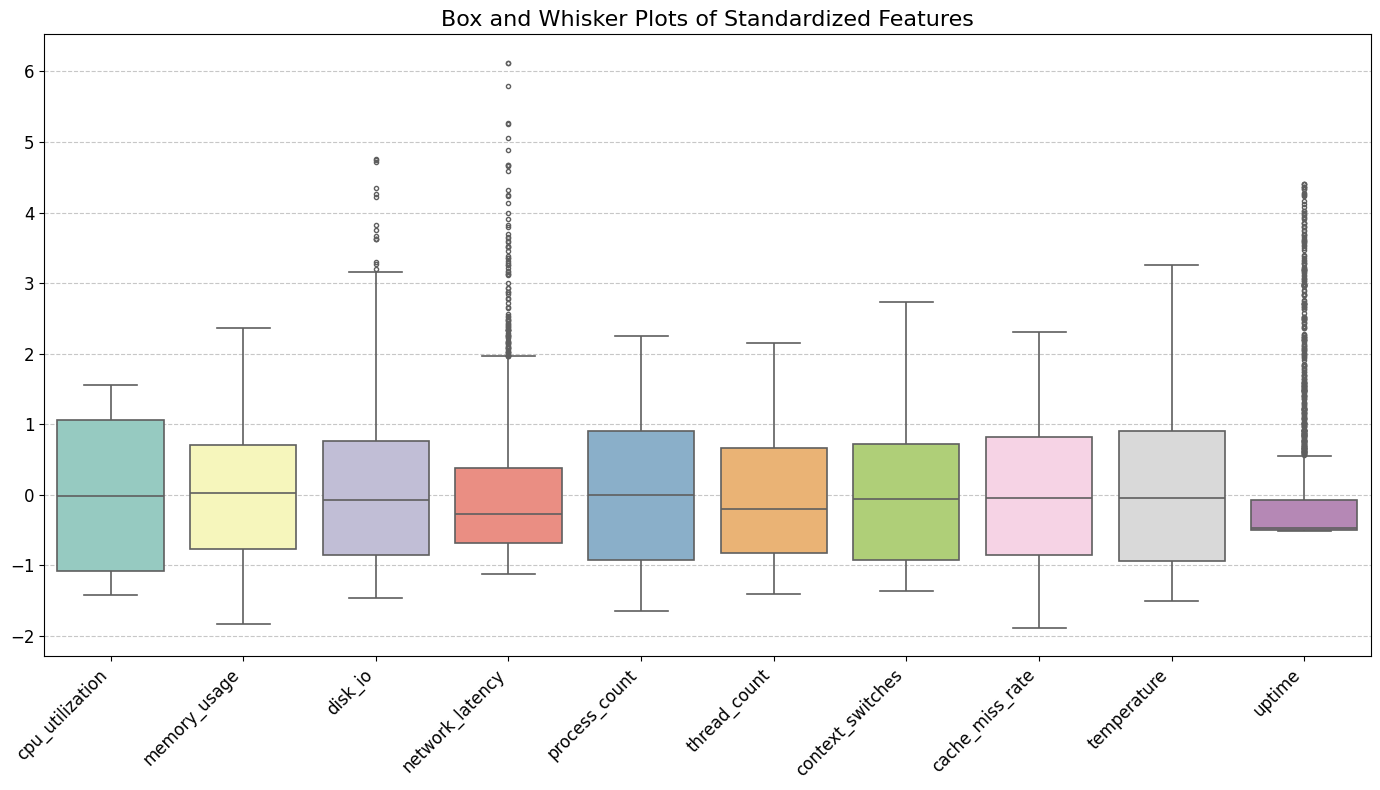

In [13]:
# Extract features only
features = df.drop(columns=[target_column])

# Standardize features for comparable scales
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert back to DataFrame for seaborn
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

plt.figure(figsize=(14, 8))
sns.boxplot(data=features_scaled_df, palette="Set3", fliersize=3, linewidth=1.2)

plt.title('Box and Whisker Plots of Standardized Features', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Correlation Radial Chart

Shows how strongly each elements is related to the feature column

(TLDR: More is better)

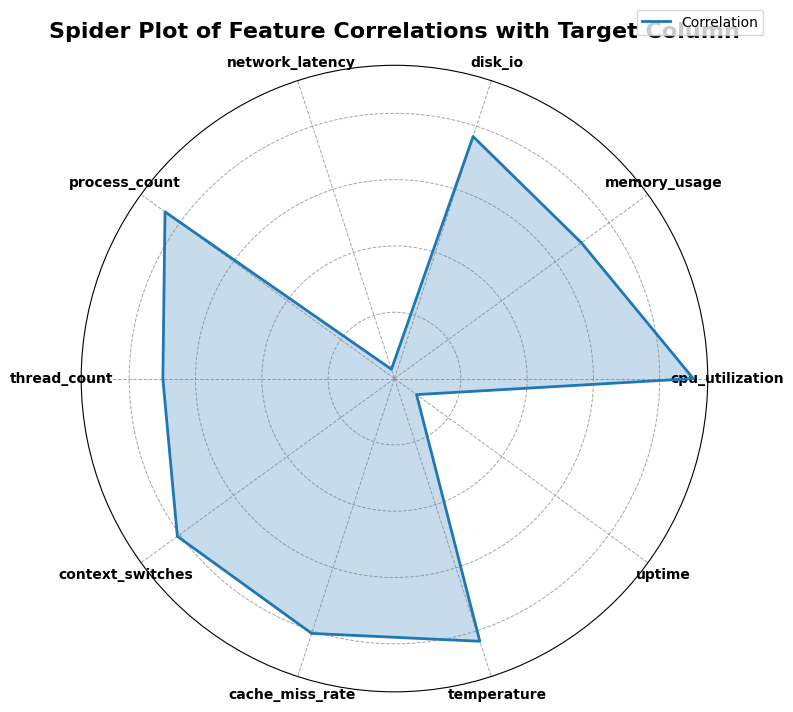

In [14]:
# Calculate correlations between features and target
target_column = "power_consumption"
feature_columns = [col for col in df.columns if col != target_column]
correlations = df[feature_columns].corrwith(df[target_column]).abs()

labels = np.array(correlations.index)
stats = correlations.values

# Complete the loop for the spider plot
stats = np.concatenate((stats, [stats[0]]))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Set up color palette with enough distinct colors for labels
palette = sns.color_palette("tab20", len(labels))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Fill the area with color
ax.fill(angles, stats, color=palette[0], alpha=0.25)
ax.plot(angles, stats, color=palette[0], linewidth=2, label='Correlation')

# ticks and labels
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')

# Add gridlines
ax.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.7)

# Add a title with padding and styling
plt.title('Spider Plot of Feature Correlations with Target Column', fontsize=16, fontweight='bold', pad=20)

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()

### Empirical Cumulative Distribution Function (ECDF)

Shows how feature values accumulate from smallest to largest, revealing the data’s spread, skewness, and presence of outliers. This helps understand how consistent or noisy a feature is

(TLDR: Steeper curve = better for model training)

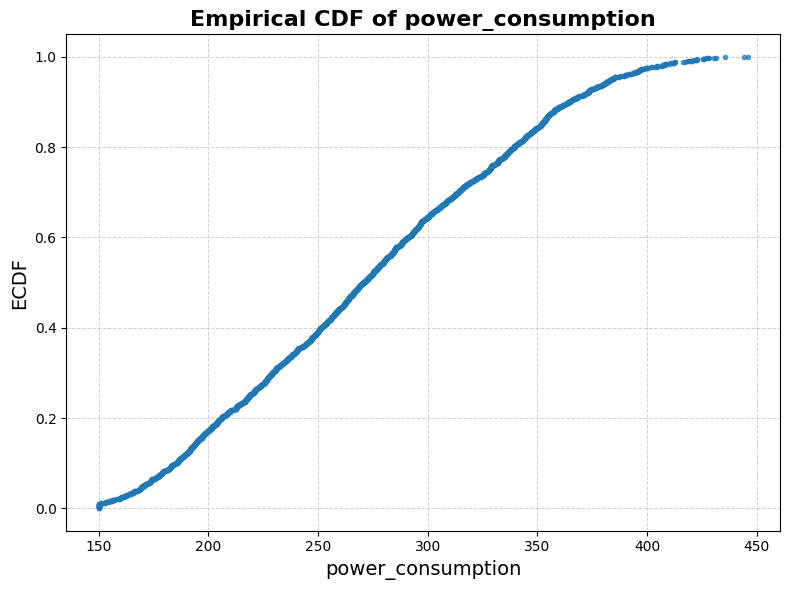

In [15]:
target = "power_consumption"

def ecdf(data):
    """Compute Empirical Cumulative Distribution Function (ECDF)."""
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n + 1) / n
    return x, y

x_ecdf, y_ecdf = ecdf(df[target])

plt.figure(figsize=(8, 6))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', color='tab:blue', alpha=0.7)
plt.title(f'Empirical CDF of {target}', fontsize=16, fontweight='bold')
plt.xlabel(target, fontsize=14)
plt.ylabel('ECDF', fontsize=14)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.show()

### Kernel Density Estimation Curve (KDE)

Shows the distribution shapes of all features to compare their variability and patterns. Reveals how each feature’s values spread and cluster, helping identify features with tight distributions, multiple modes, or skewness

(TLDR:  KDEs reveal feature distribution shapes for general understanding)

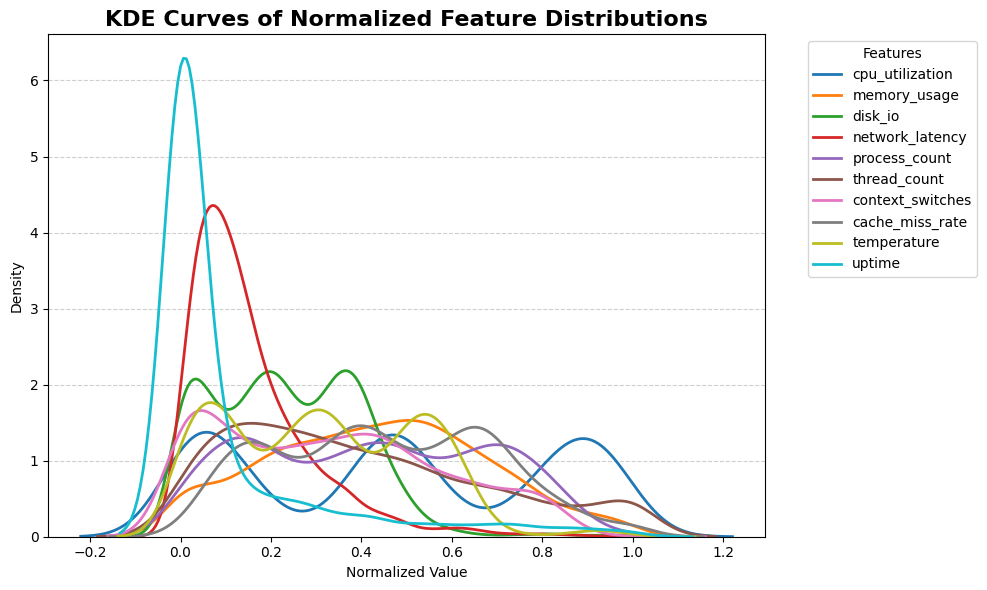

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

target_column = "power_consumption"
feature_columns = [col for col in df.columns if col != target_column]

# Normalize features between 0 and 1 for better comparison
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(df[feature_columns])

plt.figure(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(feature_columns))

for i, feature in enumerate(feature_columns):
    sns.kdeplot(features_scaled[:, i], label=feature, color=palette[i], linewidth=2, fill=False)

plt.title('KDE Curves of Normalized Feature Distributions', fontsize=16, fontweight='bold')
plt.xlabel('Normalized Value')
plt.ylabel('Density')
plt.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()